# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign start: `trials.json` is empty, so this is trial_01 of the experiment_8 loss-FUNCTION
campaign (cap MAX_TRIALS=30). There are no previous trials to read.

Frozen from the prior campaigns: schedule = exp5 winner (lr_mu 0.1669, mu_anneal 0.3455,
lr_gamma 0.4716, gamma_anneal 0.4723); bandwidth = exp7 winner (rule `target`, h_f_scale 4.0,
h_s_scale 3.6745); gamma trust region = exp6 winner (gamma_rel_cap 0.10736). Only the
distributional loss is searched here, over 2 knobs: `loss_family`
(kde | w1_2d | energy_2d | mmd_2d | w1_fwhm | cvm_fwhm) and `sigma_weight` (0-1, the weight of the
sigma_fit channel: loss = loss_FWHM + sw * loss_sigma).

Known reference points (from README/context, not from trials in this folder): the `kde` family is
the exp6 CONTROL and reproduces exp6's 0.080328 (scale factor 1.0 by construction). exp5/6/7 all
bottom out at ~0.078-0.082; the residual lives in the low-count T05/T20 mu-gamma cells where the
sim sigma_fit channel is 1.04-4.25x too narrow (FM#8/FM#6). Success bar = objective below ~0.086,
with gamma finite on all 8 cells; beating 0.0803 is a bonus.

Nothing has been measured yet in this campaign, so the only reference available for cell 3 is the
candidate table itself.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (0/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.9504636963259353}
 2 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.14415961271963373}
 3 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.31183145201048545}
 4 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.42332644897257565}
 5 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.4091991363691613}
 6 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.5495936876730595}
 7 |      - | {"loss_family": "kde", "sigma_weight": 0.7535131086748066}
 8 |      - | {"loss_family": "kde", "sigma_weight": 0.5381433132192782}
 9 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.7884287034284043}
10 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.303194829291645}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

No trials have run yet, so there is no measured reference inside this campaign; the candidate
table is all I can reason from. It is the uniform-exploration phase (0/5 recorded trials), and
the ten proposals span the six families with a spread of sigma_weight values.

Two considerations constrain a sensible first pick. (1) The two FWHM-only families in the table
(w1_fwhm candidates 3, 6, 9; cvm_fwhm candidate 4) drop the sigma -> mu link entirely, which the
physics says is the channel that even informs mu at all on real data (the count channel is dead);
they are controls and are unlikely to be the winner, though they are worth burning a trial on later
to confirm the channel story. (2) The whole point of the campaign is to test whether a
bandwidth-free discrepancy stops the optimizer trusting the mis-scaled sigma channel. The
bandwidth-free 2-D families are therefore the interesting first test.

Of the bandwidth-free 2-D proposals, candidate 5 (`w1_2d`, sigma_weight 0.409) and candidate 10
(`w1_2d`, 0.303) are the Wasserstein-1 variants, candidate 1 (`energy_2d`, 0.950) and candidate 2
(`mmd_2d`, 0.144) the others. Candidate 1 carries a very high sigma_weight (0.95), which mostly
reproduces the exp6-style sigma-heavy regime but in a new loss form; candidate 2's sigma_weight
(0.14) is quite low. Candidate 5 sits closest to the middle of the sigma_weight range and uses
Wasserstein-1, the discrepancy the project already has the most internal experience with (the
12-series used W1 quantile matching before the KDE), now applied to both channels jointly. That
makes it the cleanest first probe of the loss form: a bandwidth-free 2-D objective with a moderate
sigma channel, directly comparable to the kde control under the frozen schedule/bandwidth/cap.

I choose candidate 5.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'w1_2d', 'sigma_weight': 0.4091991363691613}
Running  1nW Trans05 ... 

μ 9.39 -> 1120.41 | γ 8.5 -> 2.74 | NLL 33.59


Running  1nW Trans20 ... 

μ 17.32 -> 81.44 | γ 8.5 -> 5.76 | NLL 5.64


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 73.73 | γ 14.1 -> 14.49 | NLL 2.65


Running 3nW Trans100 ... 

μ 175.71 -> 105.59 | γ 14.1 -> 13.66 | NLL 3.87



Total: 7.2 min


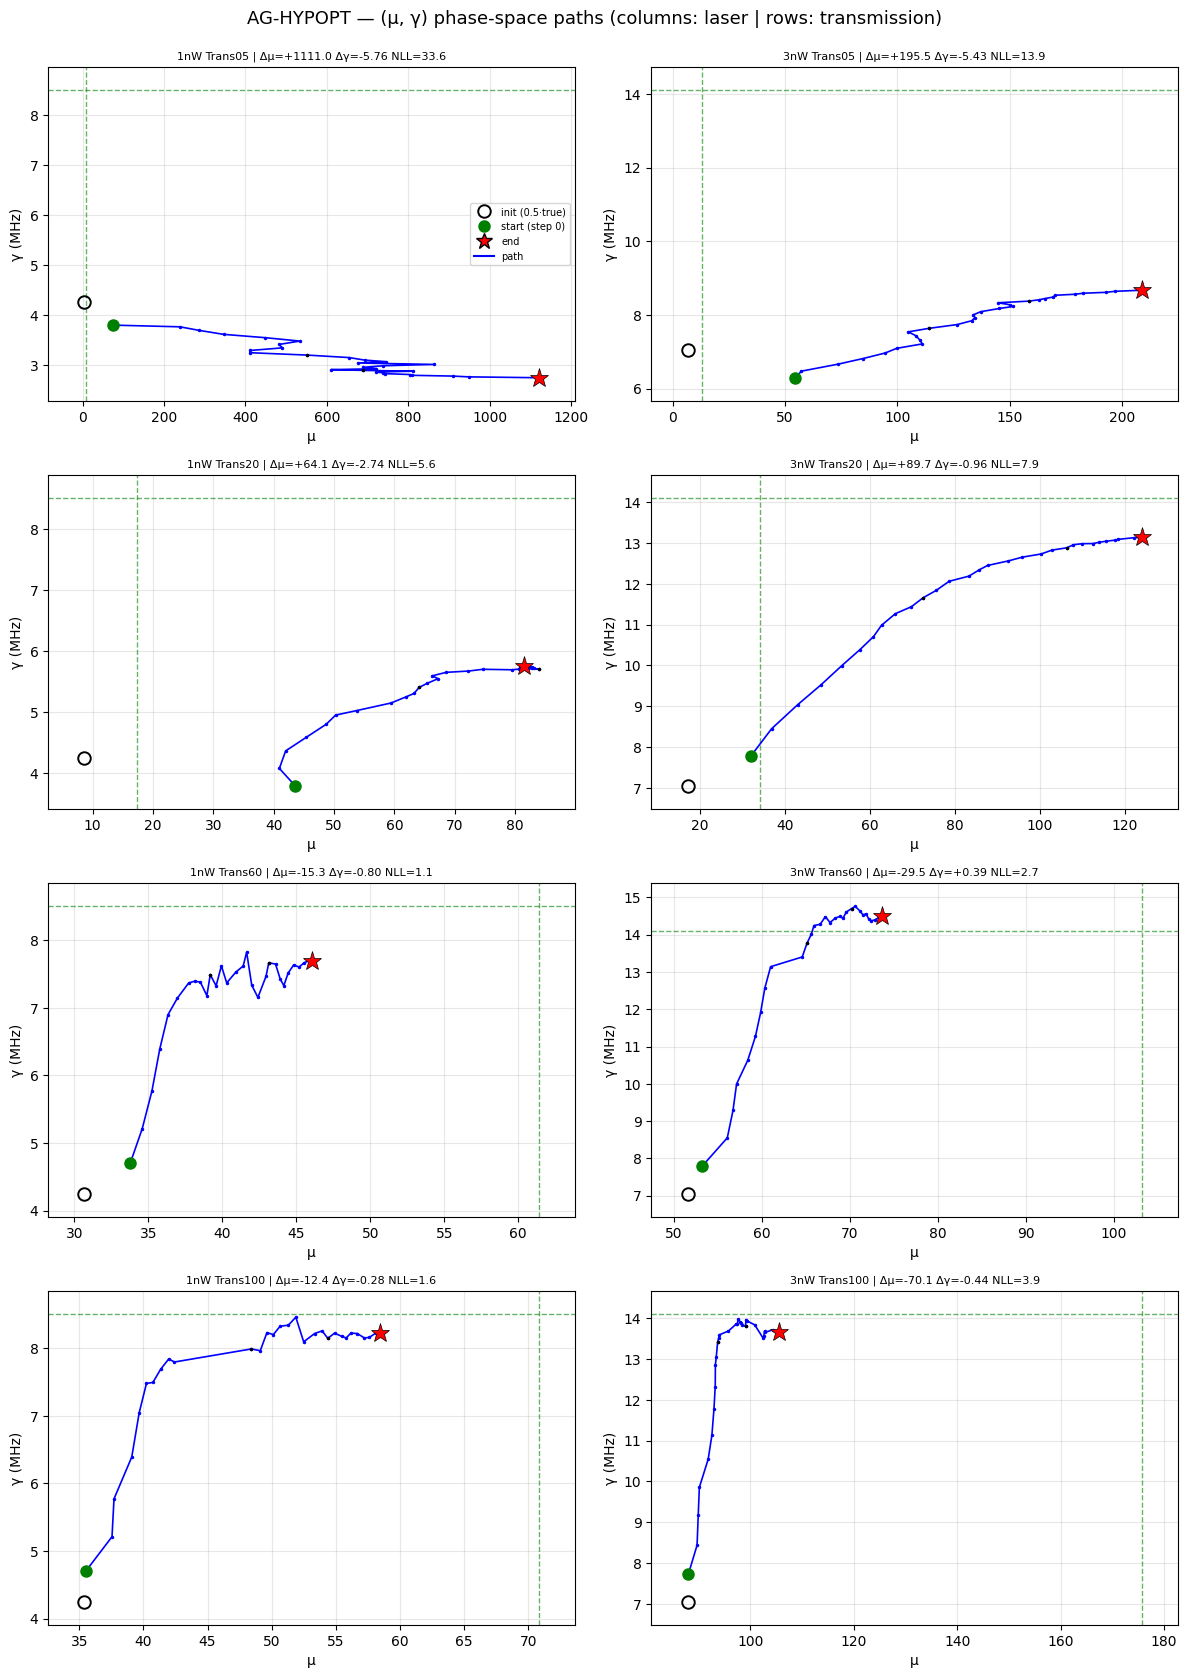

trial finished in 7.2 min
objective = 0.1982 ± 0.1057
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39 1120.41+11828.2 |     8.50    2.74   -67.8
1nW Trans20       17.32   81.44  +370.3 |     8.50    5.76   -32.3
1nW Trans60       61.37   46.07   -24.9 |     8.50    7.70    -9.4
1nW Trans100       70.82   58.41   -17.5 |     8.50    8.22    -3.2
3nW Trans05       13.20  208.71 +1480.6 |    14.10    8.67   -38.5
3nW Trans20       34.28  123.94  +261.6 |    14.10   13.14    -6.8
3nW Trans60      103.20   73.73   -28.6 |    14.10   14.49    +2.8
3nW Trans100      175.71  105.59   -39.9 |    14.10   13.66    -3.1

weighted objective (T-graded, cap=1.0) = 0.1982 | diverged cells: 0
μ: RMSE 401.702 (rel 4217.6%, bias +166.626) | γ: RMSE 3.004 (rel 30.2%, bias -2.002)


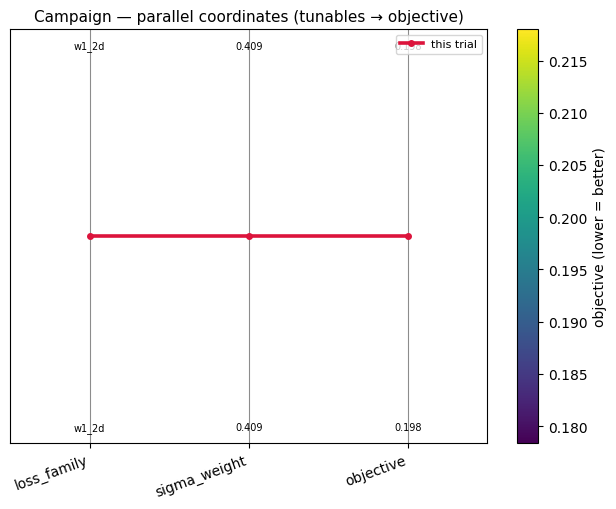

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

First trial of the campaign, so there is no previous trial to compare against; the reference is
the exp6 KDE control it must try to beat (0.080328). Chosen config: `w1_2d`,
sigma_weight = 0.4092.

Result: **objective = 0.1982 ± 0.1057** (T-weighted, capped). All 8 cells finished, 0 diverged,
gamma finite everywhere. So the run is mechanically clean but the objective is far *above* the
control (0.0803) - by ~0.12, i.e. 2.5x worse.

Per-cell (mu_fit / gamma_fit vs truth):
- 1nW T05: mu 9.39 -> 1120.41 (+11828%), gamma 8.50 -> 2.74 (-67.8%)
- 1nW T20: mu 17.32 -> 81.44 (+370%), gamma 8.50 -> 5.76 (-32.3%)
- 1nW T60: mu 61.37 -> 46.07 (-24.9%), gamma 8.50 -> 7.70 (-9.4%)
- 1nW T100: mu 70.82 -> 58.41 (-17.5%), gamma 8.50 -> 8.22 (-3.2%)
- 3nW T05: mu 13.20 -> 208.71 (+1480%), gamma 14.10 -> 8.67 (-38.5%)
- 3nW T20: mu 34.28 -> 123.94 (+262%), gamma 14.10 -> 13.14 (-6.8%)
- 3nW T60: mu 103.20 -> 73.73 (-28.6%), gamma 14.10 -> 14.49 (+2.8%)
- 3nW T100: mu 175.71 -> 105.59 (-39.9%), gamma 14.10 -> 13.66 (-3.1%)
RMSE: mu 401.7 (rel 4217.6%, bias +166.6); gamma 3.00 (rel 30.2%, bias -2.00).

The objective is entirely dominated by the low-count cells, exactly where the campaign expects
trouble (FM#8/FM#6). But the failure signature is the opposite of the KDE control's: instead of
drifting to a low-mu mode, the W1-2d mu reward drives mu *far above* truth in the low-T cells
(1nW T05 to 1120, 3nW T05 to 209, both T20s to 80-124) while gamma collapses below truth there
(1nW T05 gamma down 68%). The high-transmission cells are comparatively healthy (1nW T100 mu
-17.5%, 3nW T100 mu -39.9%, gammas within ~3% at T100). So the runaway is a low-n_target /
low-count phenomenon, not a global one.

Under the frozen FAMILY_SCALE normalization (which matches |d loss/d gamma| at the shared start),
this first data point says the Wasserstein-1 2-D loss form with a moderate sigma channel is a poor
driver for the (mu, gamma) optimizer on this benchmark - it does not reproduce the KDE control's
behaviour and is much worse on the metric.

**Summary:** Trial 01 (`w1_2d`, sw=0.409) scores 0.1982, far above the 0.0803 KDE control, with mu runaway above truth in the low-count T05/T20 cells.
**Key insight:** The bandwidth-free W1-2d reward pushes mu far above truth in low-count cells (1nW T05 -> 1120) rather than into the KDE control's low-mu mode, so the objective is dominated by the low-T mu errors.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Note for Anuar: the low-count mu runaway under W1-2d is worth watching across the other
families - if every bandwidth-free family shows it, it points at the mu reward form (r = -loss)
under a non-KDE loss, not at the gamma path; but that is a structural question and is NOT acted
on in this campaign.

CAMPAIGN BLOCKER (recorded after cells 7-9): the campaign cannot continue past trial_01. Cell 9
(the generator) raised `RuntimeError: stamp target '01' not found in the template` and no
trial_02.ipynb was created. Cause: this shipped `trial_01.ipynb` was produced by globally
replacing the template placeholders, so its own cell 9 literals were overwritten - it now reads
`_stamp('01', ...)` and `_stamp('trial_01', ...)`, but `template.ipynb` uses the placeholders
`{N}` and `trial_XXX` (cf. experiment_6/experiment_7, whose `trial_01.ipynb` cell 9 correctly
keeps `_stamp('{N}', ...)` / `_stamp('trial_XXX', ...)`). So cell 9 cannot stamp the template.
The fix is a one-line correction in this notebook's cell 9 (change the two stamp targets back to
`{N}` and `trial_XXX`, matching template.ipynb) - but cell 9 is a frozen `▶ RUN` cell and the
campaign rules forbid editing run-cell code, so the campaign is stopped here rather than
improvise. Trial_01 itself is valid and recorded; resume is blocked only on this generator bug.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 01 (w1_2d, sw=0.409) scores 0.1982, far above the 0.0803 KDE control, with mu runaway above truth in the low-count T05/T20 cells.'
KEY_INSIGHT = 'The bandwidth-free W1-2d reward pushes mu far above truth in low-count cells (1nW T05 -> 1120) rather than into the KDE control low-mu mode, so the objective is dominated by the low-T mu errors.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_01 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('01', f'{nxt:02d}')
    _stamp('trial_01', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


RuntimeError: stamp target '01' not found in the template